In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("song_recomendation_A.csv")
df.head(10)

,Track URI,Track Name,Artist Name(s),Album Name,Album Release Date,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,spotify:track:38tpcZDofjtDNunMm5w1EU,If I Could Change Your Mind,HAIM,Days Are Gone (Deluxe Edition),2013-01-01,53,"indietronica,metropopolis",0.671,0.852,2.0,-5.557,0.0,0.0425,0.01840,0.000099,0.0841,0.737,125.043,4.0
1,spotify:track:60lJebAiPbIrnLeGev6kHX,If I Ain't Got You,Alicia Keys,The Diary Of Alicia Keys,2003,0,"neo soul,pop,r&b",0.589,0.449,7.0,-9.153,1.0,0.1050,0.60700,0.000022,0.1000,0.159,118.351,3.0
2,spotify:track:1dbt3sOwRmUOLfQZSpSz9O,Truly,Lionel Richie,Lionel Richie (Expanded Edition),1982,0,soft rock,0.366,0.238,1.0,-13.853,1.0,0.0381,0.64600,0.000010,0.0876,0.131,68.362,4.0
3,spotify:track:50PeqUz1BjMw9ayNTk5O4d,I've Been Thinking About You,Londonbeat,Best! The Singles 16 Tracks,1995-11-20,69,"eurodance,hip house",0.678,0.659,11.0,-12.695,0.0,0.0396,0.02360,0.001920,0.0744,0.899,113.542,4.0
4,spotify:track:111P8I22TrLyxQm7Jcwdoy,Kung Fu Fighting,"Bus Stop, Carl Douglas",The Soul of the Kung Fu Fighter,1972-02-13,0,NaN,0.737,0.855,11.0,-10.319,0.0,0.0646,0.00475,0.000017,0.1630,0.583,116.023,4.0
5,spotify:track:6QAOkWnUrLLoDfmndW9Z3P,Love Don't Cost a Thing,Jennifer Lopez,J.Lo,2001-01-19,0,"dance pop,pop,urban contemporary",0.777,0.834,4.0,-5.129,0.0,0.0843,0.00275,0.000001,0.3610,0.660,97.527,4.0
6,spotify:track:0JhKJg5ejeQ8jq89UQtnw8,Levels - Radio Edit,Avicii,Levels,2011-10-28,0,"edm,pop,pop dance",0.620,0.881,1.0,-5.851,0.0,0.0372,0.05850,0.714000,0.3110,0.415,126.035,4.0
7,spotify:track:62FuZGFoly0h2Cb95mxNym,All Good Things (Come To An End) - Radio Edit,Nelly Furtado,All Good Things (Come To An End) [Internationa...,2006-01-01,0,"canadian latin,canadian pop,dance pop,pop",0.666,0.634,9.0,-7.861,0.0,0.0346,NaN,0.000035,0.1170,0.356,100.884,4.0
8,spotify:track:22PMfvdz35fFKYnJyMn077,Marry You,Bruno Mars,Doo-Wops & Hooligans,2010-10-05,79,"dance pop,pop",0.621,0.820,10.0,-4.865,1.0,0.0367,0.33200,0.000000,0.1040,0.452,144.905,4.0
9,spotify:track:4HaKJH8swiAIRuiU2mgr6f,Over Now (with The Weeknd),"Calvin Harris, The Weeknd",Over Now (with The Weeknd),2020-08-28,41,"dance pop,edm,electro house,house,pop,progress...",0.600,0.890,4.0,-4.106,0.0,0.0427,0.07910,0.002220,0.3000,0.668,177.995,4.0


## a) EDA

### 1. Cek Dataset Secara Keseluruhan

In [3]:
df.shape

(5000, 19)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Track URI           5000 non-null   object 
 1   Track Name          4999 non-null   object 
 2   Artist Name(s)      4999 non-null   object 
 3   Album Name          4999 non-null   object 
 4   Album Release Date  5000 non-null   object 
 5   Popularity          5000 non-null   int64  
 6   Artist Genres       4705 non-null   object 
 7   Danceability        5000 non-null   float64
 8   Energy              5000 non-null   float64
 9   Key                 5000 non-null   float64
 10  Loudness            5000 non-null   float64
 11  Mode                5000 non-null   float64
 12  Speechiness         5000 non-null   float64
 13  Acousticness        4850 non-null   float64
 14  Instrumentalness    5000 non-null   float64
 15  Liveness            5000 non-null   float64
 16  Valenc

### 2. Cek Duplikat

In [5]:
df.duplicated().sum()

9

Berdasarkan hasil yang didapatkan, dapat diketahui bahwa dalam dataset ini terdapat 9 data yang duplikat sehingga data tersebut akan di drop sebelum diproses lebih lanjut

In [6]:
df = df.drop_duplicates()

In [7]:
#Cek ulang
df.duplicated().sum()

0

### 3. Cek Missing Value

In [8]:
df.isna().sum()

Track URI               0
Track Name              1
Artist Name(s)          1
Album Name              1
Album Release Date      0
Popularity              0
Artist Genres         295
Danceability            0
Energy                  0
Key                     0
Loudness                0
Mode                    0
Speechiness             0
Acousticness          150
Instrumentalness        0
Liveness                0
Valence                 0
Tempo                 250
Time Signature          0
dtype: int64

#### - Kolom Numerik

In [9]:
num_cols = df.select_dtypes(include=["float64", "int64"]).columns

#Input missing value di kolom numerik dengan median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

#### - Kolom Kategorikal

In [10]:
cat_cols = df.select_dtypes(include=["object"]).columns

#Input missing value di kolom kategorikal dengan modus
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

#### - Cek Ulang Missing Value

In [11]:
df.isna().sum()

Track URI             0
Track Name            0
Artist Name(s)        0
Album Name            0
Album Release Date    0
Popularity            0
Artist Genres         0
Danceability          0
Energy                0
Key                   0
Loudness              0
Mode                  0
Speechiness           0
Acousticness          0
Instrumentalness      0
Liveness              0
Valence               0
Tempo                 0
Time Signature        0
dtype: int64

### 4. Cek Deskripsi Data Numerik

In [12]:
df[num_cols].describe()

,Popularity,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
count,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.00000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000
mean,37.155079,0.607737,0.684064,5.191946,-7.286228,0.702665,0.06497,0.204797,0.031152,0.186368,0.587958,121.145818,3.959728
std,29.405206,0.146796,0.190970,3.589902,3.322893,0.457131,0.06017,0.245310,0.128160,0.150364,0.239424,25.670810,0.238946
min,0.000000,0.099400,0.020500,0.000000,-23.242000,0.000000,0.02180,0.000003,0.000000,0.012000,0.033400,59.406000,1.000000
25%,0.000000,0.513000,0.564000,2.000000,-9.079000,0.000000,0.03330,0.019800,0.000000,0.089200,0.400000,103.309500,4.000000
50%,41.000000,0.619000,0.710000,5.000000,-6.492000,1.000000,0.04310,0.098300,0.000005,0.127000,0.601000,120.336000,4.000000
75%,63.000000,0.712000,0.836000,8.000000,-4.903000,1.000000,0.06830,0.303000,0.000601,0.247500,0.787000,133.034500,4.000000
max,95.000000,0.988000,0.994000,11.000000,2.769000,1.000000,0.51900,0.991000,0.985000,0.989000,0.995000,217.913000,5.000000


Berdasarkan statistik deskriptif terhadap 4.991 lagu, dataset menunjukkan karakteristik yang cukup representatif. Rata-rata popularitas berada pada tingkat menengah (mean = 37,16) dengan variasi yang cukup besar, menandakan adanya lagu yang sangat populer maupun kurang dikenal. Mayoritas lagu memiliki tingkat danceability (mean = 0,61), energy (mean = 0,68), dan valence (mean = 0,59) yang relatif tinggi, menunjukkan kecenderungan lagu yang energik, mudah ditarikan, dan bernuansa positif. Tempo rata-rata berada di kisaran 121 BPM dan didominasi oleh time signature 4/4, yang merupakan struktur ritme umum pada genre pop dan dance. Selain itu, sebagian besar lagu berada pada mode mayor, yang umumnya diasosiasikan dengan suasana ceria.

Tidak ditemukan anomali ekstrem atau outlier yang tidak wajar dalam dataset. Nilai ekstrem seperti loudness yang sangat rendah, tempo yang sangat cepat, atau acousticness mendekati 1 masih berada dalam rentang yang masuk akal secara musikal dan mencerminkan keberagaman genre, mulai dari lagu akustik, instrumental, hingga lagu berenergi tinggi. Variasi yang cukup lebar pada beberapa fitur audio merupakan karakteristik alami data musik dan tidak mengindikasikan kesalahan pencatatan. Oleh karena itu, dataset dianggap bersih dan layak digunakan untuk pembangunan sistem rekomendasi berbasis konten tanpa memerlukan penghapusan outlier, melainkan cukup dilakukan normalisasi untuk menyamakan skala fitur.

### 5. Cek Korelasi

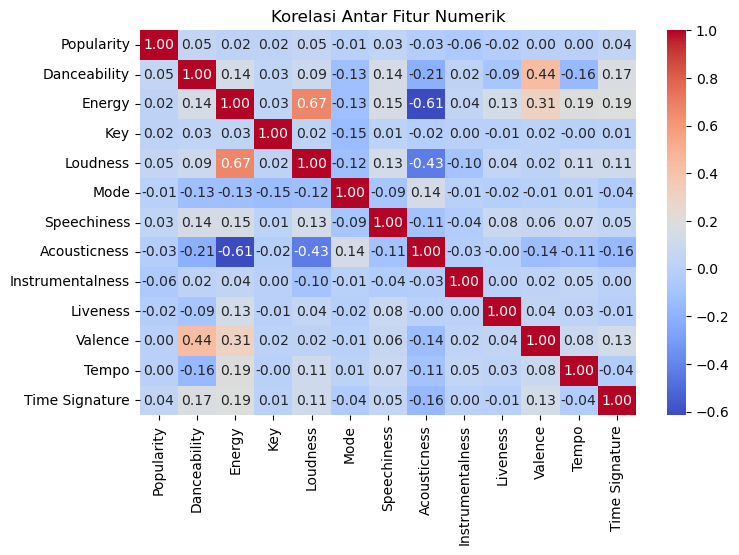

In [13]:
#Menghitung korelasi untuk kolom numerik
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Korelasi Antar Fitur Numerik")
plt.show()

Heatmap korelasi menunjukkan bahwa sebagian besar fitur audio memiliki korelasi rendah hingga sedang, sehingga setiap fitur memberikan informasi yang berbeda. Terdapat hubungan yang wajar seperti korelasi positif antara energy dan loudness serta korelasi negatif antara energy dan acousticness. Tidak ditemukan korelasi yang sangat tinggi antar fitur, sehingga tidak ada redundansi berlebihan dan seluruh fitur layak digunakan dalam sistem rekomendasi berbasis cosine similarity.

### 6. Cek Inkonsistensi

In [14]:
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    print(df[col].value_counts(dropna=False), "\n")

Track URI
spotify:track:3yrSvpt2l1xhsV9Em88Pul    2
spotify:track:6kooDsorCpWVMGc994XjWN    2
spotify:track:7hQJA50XrCWABAu5v6QZ4i    2
spotify:track:7aXM5I2koKhl6gvQqbQtPo    1
spotify:track:3dVLXaBlaNCB6lnleyWDPG    1
                                       ..
spotify:track:5uCax9HTNlzGybIStD3vDh    1
spotify:track:5RC9olve1FVs1bnIneatm8    1
spotify:track:6ZYxMiIIoNazRBBn923e9Q    1
spotify:track:5qqabIl2vWzo9ApSC317sa    1
spotify:track:1oH5Mg9dyAj15lWUmXvmFW    1
Name: count, Length: 4988, dtype: int64 

Track Name
Last Night                                       7
One                                              6
Higher                                           5
How Deep Is Your Love                            5
Stay                                             5
                                                ..
In Da Club                                       1
Emotion Sickness                                 1
Welcome to Paradise                              1
Horror Movie - R

Hasil analisis menunjukkan bahwa pengulangan pada kolom kategorikal seperti Track URI, Track Name, dan Artist Name(s) merupakan duplikasi yang wajar, misalnya lagu atau artis yang sama muncul lebih dari satu kali. Variasi tinggi pada Artist Genres mencerminkan keberagaman dan kombinasi genre musik.

In [15]:
#Reset index data
df = df.reset_index(drop=True)

In [16]:
df.shape

(4991, 19)

## b) Content-based Recommendation System

In [17]:
#Pilih fitur audio yang merepresentasikan karakter musik
audio_features = [
    'Danceability','Energy','Loudness','Speechiness',
    'Acousticness','Instrumentalness','Liveness',
    'Valence','Tempo'
]

scaler = StandardScaler()
audio_scaled = scaler.fit_transform(df[audio_features])

In [18]:
#Mengubah teks genre menjadi angka dan mengabaikan kata umum bahasa Inggris
tfidf = TfidfVectorizer(stop_words='english')
genre_tfidf = tfidf.fit_transform(df['Artist Genres'])

#Menggabungkan fitur audio dan genre agar setiap lagu punya satu vektor lengkap
feature_matrix = hstack([audio_scaled, genre_tfidf])

#Menghitung tingkat kemiripan antar lagu berdasarkan fitur tersebut
similarity = cosine_similarity(feature_matrix)

In [19]:
def recommend_songs(song_title, n=5):
    if song_title not in df['Track Name'].values:
        return "Song not found in the dataset"
    
    idx = df[df['Track Name'] == song_title].index[0]
    similarity_scores = list(enumerate(similarity[idx]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    similarity_scores = similarity_scores[1:n+1]
    
    recommendations = df.iloc[[i[0] for i in similarity_scores]][
        ['Track Name', 'Artist Name(s)', 'Album Name', 'Artist Genres']
    ]
    
    return recommendations

## c) Contoh Input

In [20]:
recommend_songs(df['Track Name'].iloc[10])

,Track Name,Artist Name(s),Album Name,Artist Genres
3732,Passenger,Powderfinger,Internationalist,"australian alternative rock,australian rock"
2611,Believe Again,Delta Goodrem,Delta,"australian pop,australian talent show"
2377,I Just Don't Know What To Do With Myself,Marcia Hines,The Essential,"australian dance,australian pop,australian rock"
772,Never Let You Go,Evermore,Real Life,"australian alternative rock,australian rock,ki..."
4223,Love Has No Pride - 2017 Remastered,Daryl Braithwaite,Days Go By: The Definitive Greatest Hits Colle...,"australian pop,australian rock"


In [21]:
recommend_songs(df['Track Name'].iloc[20])

,Track Name,Artist Name(s),Album Name,Artist Genres
539,Talk To Me,Sunny & The Sunglows,All Time Favorites: Sunny & the Sunglows,"dance pop,pop"
1197,The Rain The Park And Other Things,The Cowsills,The Cowsills,"bubblegum pop,classic garage rock,merseybeat,u..."
665,One More Try - Live,George Michael,Symphonica (Deluxe Version),new wave pop
1342,"Monday, Monday - Single Version",The Mamas & The Papas,If You Can Believe Your Eyes & Ears,"classic rock,folk,folk rock,mellow gold,psyche..."
4403,This Is My Song,Harry Secombe,The Very Best Of,"dance pop,pop"


In [22]:
recommend_songs(df['Track Name'].iloc[30])

,Track Name,Artist Name(s),Album Name,Artist Genres
1346,Unpredictable,"Olly Murs, Louisa Johnson",Unpredictable,"dance pop,pop,talent show,talent show,uk pop"
1389,Wellerman - Sea Shanty / 220 KID x Billen Ted ...,"Nathan Evans, 220 KID",Wellerman (Sea Shanty / 220 KID x Billen Ted R...,"pop dance,uk dance"
2012,Need Me,"Mashd N Kutcher, Sammi Constantine",Need Me,"dance pop,pop"
2381,This Is Heaven,Nick Jonas,This Is Heaven,"dance pop,pop"
3352,The Itch,Vitamin C,More,"dance pop,pop"


In [23]:
recommend_songs(df['Track Name'].iloc[40])

,Track Name,Artist Name(s),Album Name,Artist Genres
2858,Thinking out Loud,Ed Sheeran,x (Wembley Edition),"pop,singer-songwriter pop,uk pop"
2958,Thinking out Loud,Ed Sheeran,x (Deluxe Edition),"pop,singer-songwriter pop,uk pop"
3345,I'm Not The Only One,Sam Smith,In The Lonely Hour,"pop,uk pop"
386,The Love Club,Lorde,Pure Heroine (Extended),"art pop,metropopolis,nz pop,pop"
1836,Body Like A Back Road,Sam Hunt,Body Like A Back Road,"contemporary country,country,country pop"
